# Activity: The Random Rollout Algorithm
In this activity, you will implement the random rollout algorithm to solve a consumer choice problem. The random rollout algorithm is a Monte Carlo method that estimates the value of each state by simulating random trajectories from that state and averaging the rewards received. You will apply this algorithm to an apples and oranges purchasing problem with a budget constraint.

> __Learning Objectives:__
>
> After completing this activity, students will be able to:
> * **Formulate consumer choice problems as Markov Decision Processes:** We encode a budget-constrained purchasing problem as an MDP where states represent combinations of apples and oranges, actions correspond to movements in commodity space, and rewards reflect utility values combined with budget constraints.
> * **Implement random rollout for value estimation:** We estimate state values by sampling random trajectories from each state to a fixed depth, averaging cumulative discounted rewards to approximate the optimal value function without computing explicit transition models.
> * **Extract and compare policies from estimated value functions:** We derive decision policies from random rollout value estimates and compare them with value iteration solutions through visualization.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementation
The utility function `U(...)` computes the utility of combinations of apples and oranges using a Cobb-Douglas utility model. The function takes a tuple containing the number of apples and oranges, and the $\alpha$-vector of preference coefficients, then returns the computed utility value.


In [2]:
function U(x::Tuple{Int,Int}, α::Array{Float64,1})::Float64
    
    # get the apples, and oranges 
    apples = x[1];
    oranges = x[2];
    
    # compute the objective -
    utility = (apples^α[1])*(oranges^α[2]);
    
    # return -
    return utility;
end;

## Task 1: Compute the Optimal Number of Apples and Oranges to Purchase
We solve a constrained utility maximization problem using a Cobb-Douglas utility function. The consumer chooses quantities of apples and oranges to maximize their utility subject to a budget constraint and non-negativity constraints.

The Cobb-Douglas utility function is:

$$
\begin{equation*}
U(x_1, x_2) = x_1^{\alpha_1} x_2^{\alpha_2}
\end{equation*}
$$

where $x_1$ and $x_2$ are quantities of apples and oranges, and $\alpha_1, \alpha_2 \geq 0$ are preference coefficients. The complete constrained optimization problem is:

$$
\boxed{
\begin{align*}
\max_{x_1, x_2} \quad & U(x_1, x_2) = x_1^{\alpha_1} x_2^{\alpha_2} \\
\text{subject to} \quad & c_1 x_1 + c_2 x_2 \leq I \\
& x_1, x_2 \geq 0
\end{align*}}
$$

where $c_1$ and $c_2$ are unit prices, and $I$ is the total income (budget).

> __Problem Parameters:__
> * Preference coefficient vector: $\alpha = (0.55, 0.45)$
> * Total budget (income): $I = 50$ USD
> * Price of apples: $c_1 = 0.98$ USD per unit
> * Price of oranges: $c_2 = 1.49$ USD per unit
> * Index convention: $x_1$ = apples, $x_2$ = oranges
> * Search bounds: 0 to 100 units for each commodity

### Strategy
Use the `build(...)` method to construct an instance of `MySimpleCobbDouglasChoiceProblem` containing the problem parameters. Then pass this problem to the `solve(...)` function to find the optimal combination. The `let` block returns a named tuple that stores `true_solution::Dict`, `α::Vector{Float64}`, `c::Vector{Float64}`, and `total_budget::Float64` for use in later cells.

In [3]:
(; true_solution, α, c, total_budget) = let

    # initialize -
    α = [0.55, 0.45]; # coefficients
    c = [0.98, 1.49]; # price of x1 and x2
    total_budget = 50.0;

    # build my problem object -
    base = build(MySimpleCobbDouglasChoiceProblem, (
    
        initial = 0.1*ones(2), # initial guess
        α = α, # coefficients
        c = c, # price of x1 and x2
        I = total_budget, # income
    
        # how much of x₁ and x₂ can be we buy?
        bounds = [
            0.0 100.0; # L U
            0.0 100.0; # L U
        ]
    ));

    # call the solve function. This will return a dictionary -
    true_solution = solve(base);

    (; true_solution, α, c, total_budget); # return the solution
end;

This is MadNLP version v0.9.2, running with MUMPS v5.8.2



Number of nonzeros in constraint Jacobian............:        2
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        2
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du inf_compl lg(mu) lg(rg) alpha_pr ir ls


   0 -1.0000000e-01 0.00e+00 4.71e-01 9.99e+01  -1.0     -   0.00e+00  1  0 
   1 -2.4892203e-01 0.00e+00 3.46e-01 3.50e+01  -1.0     -   1.00e+00  1  1h
   2 -6.2184744e+00 3.55e-15 2.34e-01 3.12e+01  -1.0     -   1.00e+00  1  1f
   3 -2.0654568e+01 7.11e-15 2.32e-01 1.87e+01  -1.0     -   9.46e-01  1  1f
   4 -2.1133540e+01 0.00e+00 2.72e-03 1.73e+00  -1.0     -   1.00e+00  1  1h
   5 -2.1133155e+01 0.00e+00 2.30e-04 1.13e-01  -1.0     -   1.00e+00  1  1h
   6 -2.1229366e+01 0.00e+00 4.12e-06 3.42e-03  -2.5     -   1.00e+00  1  1h
   7 -2.1232782e+01 0.00e+00 5.67e-09 2.34e-06  -5.7     -   1.00e+00  1  1h
   8 -2.1232785e+01 7.11e-15 3.00e-15 2.51e-09  -8.6     -   1.00e+00  1  1h

Number of Iterations....: 8

                                   (scaled)                 (unscaled)
Objective...............:  -2.1232784729061475e+01   -2.1232784729061475e+01
Dual infeasibility......:   2.9976021664879227e-15    2.9976021664879227e-15
Constraint violation....:   7.1054273576010019e-15  

What is the __true__ optimal combination of apples and oranges?

In [4]:
optimal_apples = true_solution["argmax"][1] |> x-> round(x,digits=0) |> Int
optimal_oranges = true_solution["argmax"][2] |> x-> round(x,digits=0) |> Int
println("(apples, oranges) = ($(optimal_apples),$(optimal_oranges))")

(apples, oranges) = (28,15)


___

## Task 2: Solve the Apples and Oranges Problem Using Value Iteration
In this task, we formulate and solve the apples and oranges problem as a Markov Decision Process (MDP) using value iteration.

To solve this problem as a Markov Decision Process, we first set up the world model. We treat the purchase decision as navigation in a 2D space where each position $(x, y)$ represents a combination of $x$ apples and $y$ oranges. The goal is to reach the budget-optimal combination through sequential moves in this commodity space.

Let's set up the world parameters by defining the grid dimensions, number of actions (left, right, up, down), and discount factor:

In [5]:
number_of_rows = 30
number_of_cols = 30
nactions = 4;
nstates = (number_of_rows*number_of_cols);
𝒮 = range(1,stop=nstates,step=1) |> collect;
𝒜 = range(1,stop=nactions,step=1) |> collect;
γ = 0.95;

Next, set up the reward structure by creating the `rewards::Dict{Tuple{Int,Int}, Float64}` dictionary, which maps $(x,y)$ coordinates to reward values. 

This dictionary contains the utility values associated with each combination of apples and oranges, with special emphasis on the optimal solution.


In [6]:
my_objective_value = U((optimal_apples, optimal_oranges), α)
rewards = Dict{Tuple{Int,Int}, Float64}()
rewards[(optimal_apples, optimal_oranges)] = my_objective_value;

# setup set of absorbing states -
absorbing_state_set = Set{Tuple{Int,Int}}()
push!(absorbing_state_set, (optimal_apples, optimal_oranges));

Now build an instance of the `MyRectangularGridWorldModel` type, which represents the 2D commodity space as a grid world. Pass the grid dimensions and reward structure to the `build(...)` method to construct the `world` instance:


In [7]:
world = build(MyRectangularGridWorldModel, 
    (nrows = number_of_rows, ncols = number_of_cols, rewards = rewards));

### Construct the MDP Components

To apply value iteration, we construct the formal MDP components from the grid world model.

#### Reward Function $R(s, a)$
We encode the reward function as an `R::Array{Float64,2}` matrix with dimensions $|\mathcal{S}| \times |\mathcal{A}|$ where entry $R[s,a]$ gives the immediate reward for taking action $a$ from state $s$. This computation also returns `soft_wall_set::Set{Tuple{Int,Int}}`, the set of $(x,y)$ positions that violate the budget constraint.

> __Reward Structure:__
> * Optimal combination: High utility value from Cobb-Douglas function
> * Regular positions within budget: Utility value computed from Cobb-Douglas function
> * Positions exceeding budget: $-1000$ (step cost)
> * Out-of-bounds positions: $-50000$ (large penalty for invalid moves)
> * Absorbing (optimal) state: $0$ (the terminal reward is earned once, on the transition into this state, not repeatedly while occupying it)

For each state-action pair, we compute the resulting position and assign the appropriate reward:

In [8]:
R, soft_wall_set = let

    R = zeros(nstates, nactions);
    fill!(R, 0.0)
    for s ∈ 𝒮
        for a ∈ 𝒜
            
            Δ = world.moves[a];
            current_position = world.coordinates[s]
            new_position =  current_position .+ Δ
            
            if (haskey(world.states, new_position) == true)
                if (haskey(rewards, new_position) == true)
                    R[s,a] = rewards[new_position];
                else
                    R[s,a] = U(new_position, α);
                end
            else
                R[s,a] = -50000.0; # we are off the grid, big negative penalty
            end
        end
    end

    # setup soft walls -
    soft_wall_set = Set{Tuple{Int,Int}}();
    for s ∈ 𝒮
        
        # get the position -
        current_position = world.coordinates[s]
        
        # does this position violate the budget?
        budget_violation = max(0.0, c[1]*current_position[1]+c[2]*current_position[2] - total_budget)
        if (budget_violation ≥ 1.0)
            push!(soft_wall_set, current_position)
        end
    end

    for s ∈ 𝒮
        current_position = world.coordinates[s]
        for a ∈ 𝒜
            Δ = world.moves[a];
            new_position =  current_position .+ Δ
            
            if (in(new_position, soft_wall_set) == true)
            R[s,a] = -1000.0  
            end
        end
    end

    # absorbing states self-loop with zero reward - the terminal reward is earned once, on the
    # transition INTO the absorbing state, not repeatedly while sitting in it (so U(absorbing) = 0) -
    for s ∈ 𝒮
        current_position = world.coordinates[s]
        if (in(current_position, absorbing_state_set) == true)
            for a ∈ 𝒜
                R[s,a] = 0.0
            end
        end
    end

    R, soft_wall_set # return
end

([-50000.0 1.4640856959456254 -50000.0 1.3660402567543954; -50000.0 2.0 1.0 1.639474116758873; … ; -1000.0 -50000.0 -1000.0 -1000.0; -1000.0 -50000.0 -1000.0 -50000.0], Set([(23, 27), (22, 28), (29, 19), (25, 18), (25, 24), (15, 29), (27, 26), (27, 17), (26, 27), (18, 24)  …  (29, 29), (14, 30), (28, 16), (23, 20), (13, 26), (17, 29), (28, 18), (12, 27), (26, 20), (28, 24)]))

#### Transition Function $T(s, s', a)$
Next, construct the transition function `T::Array{Float64,3}`, which describes the environment dynamics. We encode this as a $|\mathcal{S}| \times |\mathcal{S}| \times |\mathcal{A}|$ array where $T[s, s', a]$ gives the probability of transitioning to state $s'$ when taking action $a$ from state $s$.

> __Deterministic Transitions:__
> * If action $a$ from state $s$ leads to a valid position within the grid (and not from an absorbing state), then $T[s, s', a] = 1$ where $s'$ is the resulting state
> * If the action would take us outside the grid or we are already in an absorbing state, then $T[s, s, a] = 1$ (we remain in the current state)

This captures deterministic movement in commodity space where actions have predictable outcomes:


In [9]:
T = let
    T = Array{Float64,3}(undef, nstates, nstates, nactions);
    fill!(T, 0.0)
    
    for a ∈ 𝒜
    
        Δ = world.moves[a];
    
        for s ∈ 𝒮
            current_position = world.coordinates[s]
            new_position =  current_position .+ Δ
            if (haskey(world.states, new_position) == true && 
                in(current_position, absorbing_state_set) == false)
                s′ = world.states[new_position];
                T[s, s′,  a] = 1.0
            else
                T[s, s,  a] = 1.0
            end
        end
    end
    T;
end

900×900×4 Array{Float64, 3}:
[:, :, 1] =
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.

### Build and Solve the MDP

Now construct a Markov Decision Process instance and solve it using value iteration. The solution provides the optimal value function and policy for reference comparison.

First, construct an instance of `MyMDPProblemModel`, which encapsulates all necessary components for solving the problem. Pass the states $\mathcal{S}$, actions $\mathcal{A}$, transition matrix $T$, reward matrix $R$, and discount factor $\gamma$ to the `build(...)` method:


In [10]:
m = build(MyMDPProblemModel, (𝒮 = 𝒮, 𝒜 = 𝒜, T = T, R = R, γ = γ));

Next, call the `solve(...)` method by passing a `value_iteration_model` instance and the MDP model `m`. The `solve(...)` method iteratively computes the optimal value function $U^*(s)$ and returns it as `value_iteration_solution::MyValueFunctionPolicy`:

In [11]:
value_iteration_solution = let

    k_max = 250; # maximum number of iterations
    value_iteration_model = MyValueIterationModel(k_max); # takes k_max as argument
    solution = solve(value_iteration_model,m);
    
    # solution -
    solution
end;

Extract the action-value function $Q(s, a)$ from the optimal value function $U^*(s)$. Use the `Q(...)` function with the MDP model and solution to compute the action-value function and save it in the `my_Q` variable:


In [12]:
my_Q = Q(m, value_iteration_solution.U)

900×4 Matrix{Float64}:
 -49814.3      195.469  -49814.3       195.371
 -49806.0      204.216     186.696     203.761
 -49797.9      212.76      195.371     211.881
 -49790.0      221.068     203.761     219.737
 -49782.3      229.13      211.881     227.32
 -49774.9      236.927     219.737     234.637
 -49767.8      244.459     227.32      241.691
 -49760.9      251.729     234.637     248.487
 -49754.2      258.736     241.691     255.023
 -49747.8      265.479     248.487     261.299
 -49741.6      271.955     255.023     267.316
 -49735.7      278.165     261.299     273.073
 -49730.1      284.107     267.316     278.572
      ⋮                             
  -3363.96  -53195.8     -3363.96    -4985.98
  -4195.76  -53986.0     -4195.76    -5736.68
  -4985.98  -54736.7     -4985.98    -6449.84
  -5736.68  -55449.8     -5736.68    -7127.35
  -6449.84  -56127.4     -6449.84    -7770.98
  -7127.35  -56771.0     -7127.35    -8382.43
  -7770.98  -57382.4     -7770.98    -8963.31
  -8382.

Compute the optimal policy $\pi^*(s)$ from the action-value function using the `policy(...)` function. This extracts the best action at each state and saves it in the `my_π` variable:


In [13]:
my_π = policy(my_Q)

900-element Vector{Int64}:
 2
 2
 2
 2
 2
 2
 2
 2
 2
 2
 2
 2
 2
 ⋮
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1

### Visualize the Value Iteration Policy
The code below visualizes the optimal policy by showing the path from a starting position to the optimal combination. The green circle marks the optimal combination of apples and oranges, gray areas show budget violations, and the blue path shows the trajectory following the optimal policy.

Specify a starting position $(apples, oranges)$ by setting the `initial_site` variable:

In [14]:
initial_site = (1,10); # horizontal, vertical

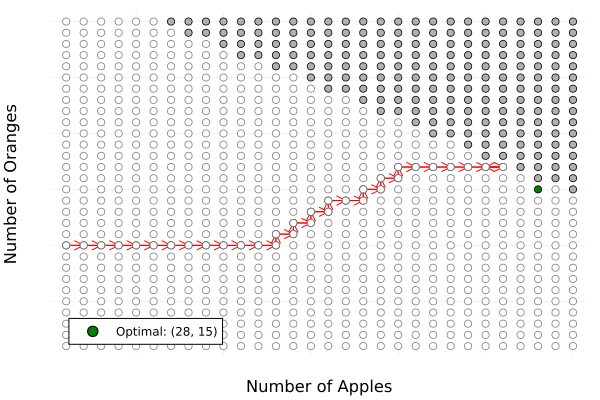

In [15]:
let
    # draw the path -
    p = plot();
    hit_absorbing_state = false
    s = world.states[initial_site];
    visited_sites = Set{Tuple{Int,Int}}();
    push!(visited_sites, initial_site);
    
    while (hit_absorbing_state == false)
        current_position = world.coordinates[s]
        a = my_π[s];
        Δ = world.moves[a];
        new_position =  current_position .+ Δ
        scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, msc=:black, c=:blue)
        plot!([current_position[1], new_position[1]],[current_position[2], new_position[2]], label="", arrow=true, lw=1, c=:red)
        
        if (in(new_position, absorbing_state_set) == true || in(new_position, visited_sites) == true)
            hit_absorbing_state = true;
        else
            s = world.states[new_position];
            push!(visited_sites, new_position);
        end
    end
    
    # draw the grid -
    for s ∈ 𝒮
        current_position = world.coordinates[s]
        a = my_π[s];
        Δ = world.moves[a];
        new_position =  current_position .+ Δ
        
        if (haskey(rewards, current_position) == true && rewards[current_position] == my_objective_value)
            scatter!([current_position[1]],[current_position[2]], label="Optimal: $(current_position)", c=:green, ms=4, legend=:bottomleft)
        elseif (in(current_position, soft_wall_set) == true)
            scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, c=:gray69, ms=4)
        else
            scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, msc=:gray50, c=:white)
        end
    end
    xlabel!("Number of Apples",fontsize=18)
    ylabel!("Number of Oranges",fontsize=18)
    current()
end

## Task 3: Solve the Apples and Oranges Problem Using Random Rollout

The random rollout algorithm provides an alternative approach to value iteration. Instead of computing explicit transition models and iteratively updating values, random rollout estimates the value of each state by sampling random trajectories from that state to a fixed search depth, then averaging the cumulative discounted rewards.

### Algorithm Overview

> __Random Rollout Algorithm:__
> 1. For each state $s$, generate multiple random trajectories
> 2. From state $s$, take $d$ random steps (explore to depth $d$)
> 3. Accumulate discounted rewards along each trajectory: $R = \sum_{t=0}^{d} \gamma^t r_t$
> 4. Estimate $U(s) \approx \mathbb{E}[R]$ by averaging over all trajectories
> 5. Extract policy by selecting actions that maximize the estimated $Q(s, a)$ values

This Monte Carlo approach requires no explicit system model and naturally handles stochastic environments.

### Implementation

First, set the rollout depth $d$, which specifies how many steps we explore from each state. We wrap this parameter in the `MyRandomRolloutModel` type:


In [16]:
d = 200;
random_rollout_model = MyRandomRolloutModel(d);

Now, compute the estimated value for each state by running random rollouts. For each state $s \in \mathcal{S}$, call the `solve(...)` function with the random rollout model, MDP model, world, and starting state. This function explores random trajectories from that state and returns the estimated value, which we store in `utility_array::Vector{Float64}`:

In [17]:
utility_array = let
    arr = Array{Float64,1}();
    for s ∈ 𝒮
        value = solve(random_rollout_model,m,world,s);
        push!(arr, value)
    end
    arr
end;

Extract the action-value function $Q(s, a)$ from the estimated value array using the `Q(...)` function:


In [18]:
my_Q_random_rollout = Q(m, utility_array);

Compute the policy $\pi(s)$ from the action-value function using the `policy(...)` function:


In [19]:
my_π_random_rollout = policy(my_Q_random_rollout);

### Visualize the Random Rollout Policy
The code below visualizes the policy derived from random rollout value estimates. The green circle marks the optimal combination, gray areas show budget violations, and the red path shows the trajectory following the random rollout policy.

Specify a starting position by setting the `random_rollout_startstate` variable:

In [20]:
random_rollout_startstate = (28,7);

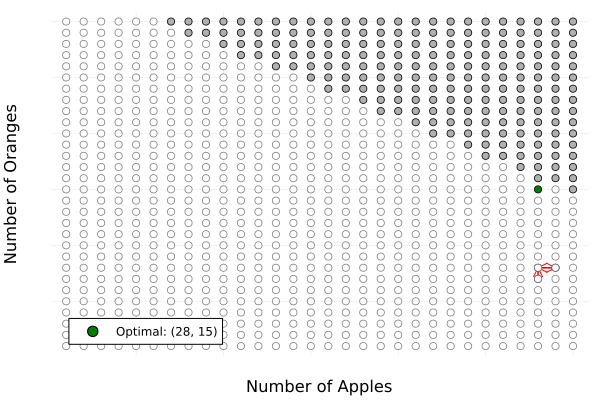

In [21]:
let
    # draw the path -
    p = plot();
    hit_absorbing_state = false
    initial_site = random_rollout_startstate;
    s = world.states[initial_site];
    visited_sites = Set{Tuple{Int,Int}}();
    push!(visited_sites, initial_site);
    my_π = my_π_random_rollout;
    
    while (hit_absorbing_state == false)
        current_position = world.coordinates[s]
        a = my_π[s];
        Δ = world.moves[a];
        new_position =  current_position .+ Δ
        scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, msc=:black, c=:blue)
        plot!([current_position[1], new_position[1]],[current_position[2], new_position[2]], label="", arrow=true, lw=1, c=:red)
        
        if (in(new_position, absorbing_state_set) == true || in(new_position, visited_sites) == true)
            hit_absorbing_state = true;
        else
            s = world.states[new_position];
            push!(visited_sites, new_position);
        end
    end
    
    # draw the grid -
    for s ∈ 𝒮
        current_position = world.coordinates[s]
        a = my_π[s];
        Δ = world.moves[a];
        new_position =  current_position .+ Δ
        
        if (haskey(rewards, current_position) == true && rewards[current_position] == my_objective_value)
            scatter!([current_position[1]],[current_position[2]], label="Optimal: $(current_position)", c=:green, ms=4, legend=:bottomleft)
        elseif (in(current_position, soft_wall_set) == true)
            scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, c=:gray69, ms=4)
        else
            scatter!([current_position[1]],[current_position[2]], label="", showaxis=:false, msc=:gray50, c=:white)
        end
    end
    xlabel!("Number of Apples",fontsize=18)
    ylabel!("Number of Oranges",fontsize=18)
    current()
end

___

## Summary
In this activity, we implemented the random rollout algorithm to solve a budget-constrained consumer choice problem and compared it with value iteration.

> __Key Takeaways:__
> 
> * **MDP formulation of consumer choice:** We encoded a purchase decision problem as an MDP where states represent commodity combinations, actions enable movement through commodity space, rewards reflect Cobb-Douglas utility values, and budget constraints act as soft barriers that penalize overspending.
> * **Random rollout value estimation:** We estimated state values using Monte Carlo trajectory sampling without constructing explicit models, exploring random paths to a fixed depth and averaging cumulative rewards to approximate $U(s)$ for policy derivation.
> * **Algorithm comparison:** We derived policies from both value iteration and random rollout methods, highlighting how the two approaches differ in computational requirements and model assumptions.

The random rollout algorithm demonstrates how Monte Carlo sampling provides a model-free alternative to dynamic programming, particularly useful when transition models are difficult to specify or when real-time decision-making is required.
___